In [3]:
import pandas as pd
import numpy as np
import os

# Load activity labels
activity_labels = pd.read_csv(
    '../data/UCI HAR Dataset/activity_labels.txt', 
    sep=' ', header=None, names=['id', 'activity']
)
print(activity_labels)

# Load training data
X_train = pd.read_csv(
    '../data/UCI HAR Dataset/train/X_train.txt', 
    sep=r'\s+', header=None
)
y_train = pd.read_csv(
    '../data/UCI HAR Dataset/train/y_train.txt', 
    header=None, names=['activity_id']
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"\nClass distribution:\n{y_train['activity_id'].value_counts().sort_index()}")

   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING

Training data shape: (7352, 561)
Training labels shape: (7352, 1)

Class distribution:
activity_id
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


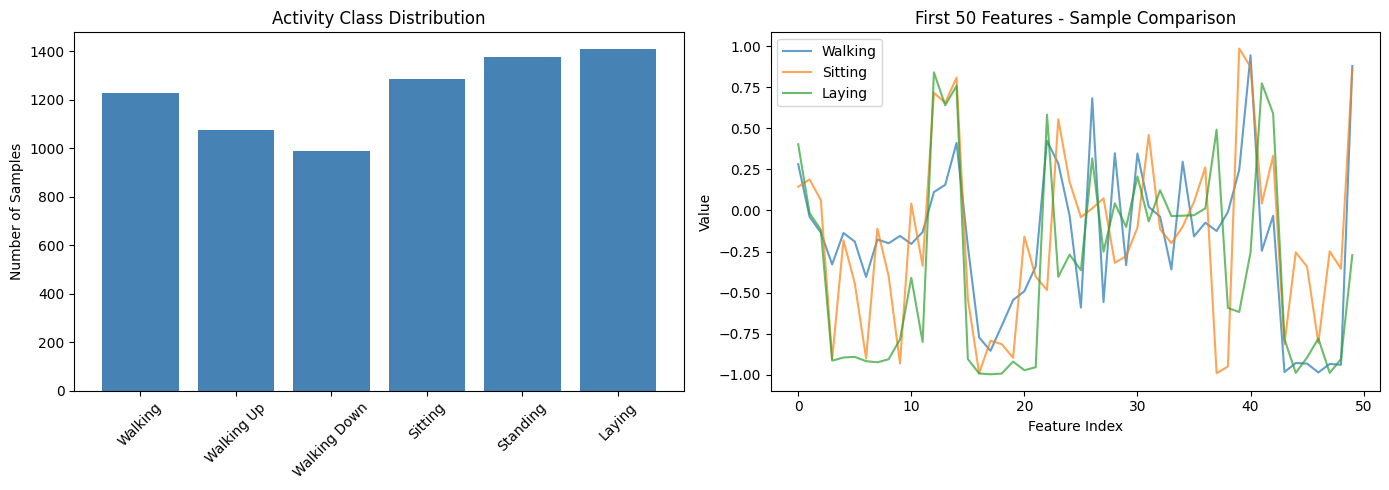

Plot saved to results/data_exploration.png


In [4]:
import matplotlib.pyplot as plt

# Activity name mapping
activities = {1: 'Walking', 2: 'Walking Up', 3: 'Walking Down', 
              4: 'Sitting', 5: 'Standing', 6: 'Laying'}

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class distribution
counts = y_train['activity_id'].value_counts().sort_index()
axes[0].bar([activities[i] for i in counts.index], counts.values, color='steelblue')
axes[0].set_title('Activity Class Distribution')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Plot first 5 features for different activities
for act_id in [1, 4, 6]:  # Walking, Sitting, Laying
    mask = y_train['activity_id'] == act_id
    sample = X_train[mask].iloc[0, :50]  # first 50 features of first sample
    axes[1].plot(sample.values, label=activities[act_id], alpha=0.7)

axes[1].set_title('First 50 Features - Sample Comparison')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/data_exploration.png', dpi=150)
plt.show()
print("Plot saved to results/data_exploration.png")

In [5]:
def load_signals(subset, base_path='../data/UCI HAR Dataset'):
    signal_types = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    signals = []
    for signal in signal_types:
        filepath = os.path.join(base_path, subset, 'Inertial Signals', f'{signal}_{subset}.txt')
        data = pd.read_csv(filepath, sep=r'\s+', header=None)
        signals.append(data.values)
    return np.stack(signals, axis=-1)

X_train_raw = load_signals('train')
X_test_raw = load_signals('test')

y_test = pd.read_csv(
    '../data/UCI HAR Dataset/test/y_test.txt',
    header=None, names=['activity_id']
)

print(f"Raw training data shape: {X_train_raw.shape}")
print(f"Raw test data shape: {X_test_raw.shape}")
print(f"Each sample: {X_train_raw.shape[1]} timesteps x {X_train_raw.shape[2]} sensor channels")

Raw training data shape: (7352, 128, 9)
Raw test data shape: (2947, 128, 9)
Each sample: 128 timesteps x 9 sensor channels


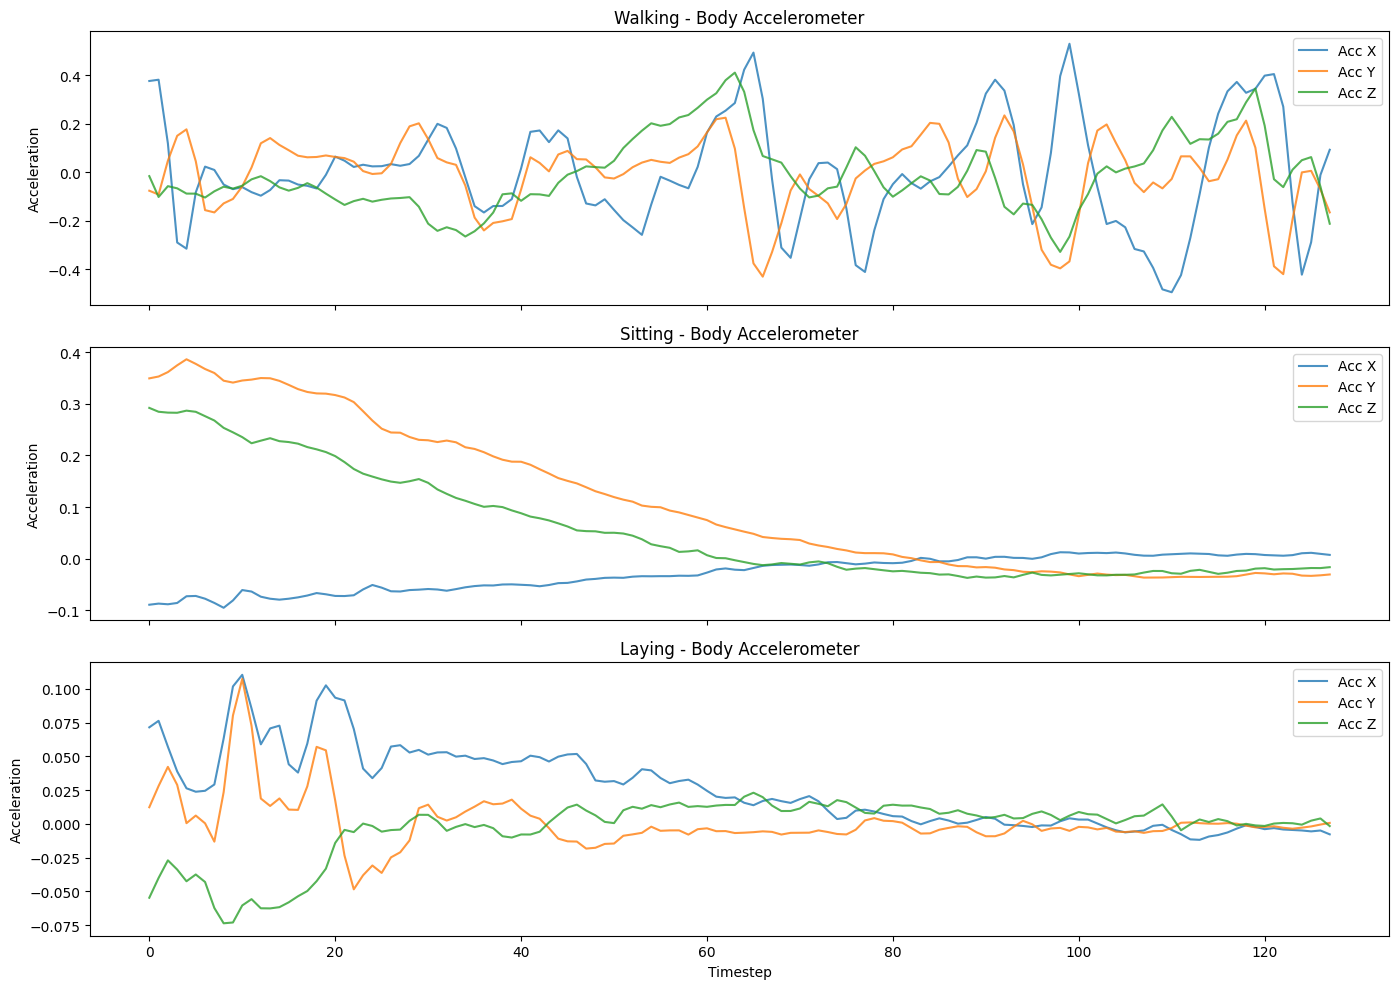

In [6]:
# Compare raw accelerometer signals across three activities with very different
# movement profiles: Walking (high-frequency periodic), Sitting (near-static),
# and Laying (near-static, different orientation). Showing these three makes
# the class-separability visually obvious before we train any model.
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (act_id, act_name) in enumerate([(1, 'Walking'), (4, 'Sitting'), (6, 'Laying')]):
    # Boolean mask over the 7352 training samples, selecting only this activity
    mask = y_train['activity_id'].values == act_id
    # Grab the first window for this activity: shape (128, 9) = 128 timesteps x 9 channels
    sample = X_train_raw[mask][0]
    # Plot the three body-accelerometer channels (indices 0,1,2 in the stacked signal array)
    axes[i].plot(sample[:, 0], label='Acc X', alpha=0.8)
    axes[i].plot(sample[:, 1], label='Acc Y', alpha=0.8)
    axes[i].plot(sample[:, 2], label='Acc Z', alpha=0.8)
    axes[i].set_title(f'{act_name} - Body Accelerometer')
    axes[i].set_ylabel('Acceleration')
    axes[i].legend(loc='upper right')

# x-axis is shared; label only the bottom subplot
axes[2].set_xlabel('Timestep')
plt.tight_layout()
plt.savefig('../results/raw_signals_comparison.png', dpi=150)
plt.show()

In [7]:
# ============================================================
# Data Preparation for PyTorch
# 
# Steps:
# 1. Normalize each sensor channel using z-score (mean=0, std=1)
#    using training set statistics only (prevents data leakage)
# 2. Convert activity labels from 1-6 to 0-5 (PyTorch requirement)
# 3. Create a PyTorch Dataset class that reshapes data to
#    (samples, channels, timesteps) for Conv1d layers
# 4. Wrap in DataLoaders for batched training
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader

# Step 1: Normalize per channel using training set statistics
train_mean = X_train_raw.mean(axis=(0, 1))
train_std = X_train_raw.std(axis=(0, 1))

X_train_norm = (X_train_raw - train_mean) / train_std
X_test_norm = (X_test_raw - train_mean) / train_std

# Step 2: Convert labels to 0-indexed (PyTorch expects 0 to num_classes-1)
y_train_arr = y_train['activity_id'].values - 1
y_test_arr = y_test['activity_id'].values - 1

# Step 3: Custom Dataset class
class HARDataset(Dataset):
    def __init__(self, X, y):
        # Permute from (samples, timesteps, channels) to (samples, channels, timesteps)
        # Conv1d expects input shape: (batch, channels, length)
        self.X = torch.FloatTensor(X).permute(0, 2, 1)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Step 4: Create DataLoaders
train_dataset = HARDataset(X_train_norm, y_train_arr)
test_dataset = HARDataset(X_test_norm, y_test_arr)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Verify shapes
sample_X, sample_y = next(iter(train_loader))
print(f"Batch input shape: {sample_X.shape}")
print(f"Batch label shape: {sample_y.shape}")
print(f"Label range: {sample_y.min()} to {sample_y.max()}")

Batch input shape: torch.Size([64, 9, 128])
Batch label shape: torch.Size([64])
Label range: 0 to 5


In [8]:
# ============================================================
# 1D CNN Model for Human Activity Recognition
#
# Architecture:
# - 3 convolutional blocks, each with Conv1d -> BatchNorm -> ReLU -> MaxPool
# - Dropout for regularization
# - Global Average Pooling to collapse the time dimension
# - Fully connected classification head (6 activity classes)
#
# Input shape: (batch, 9 channels, 128 timesteps)
# Output shape: (batch, 6 classes)
# ============================================================

import torch.nn as nn

class HARConvNet(nn.Module):
    def __init__(self, n_channels=9, n_classes=6):
        super(HARConvNet, self).__init__()
        
        # Block 1: 9 input channels -> 64 filters
        self.block1 = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)  # 128 -> 64
        )
        
        # Block 2: 64 -> 128 filters
        self.block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2)  # 64 -> 32
        )
        
        # Block 3: 128 -> 256 filters
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2)  # 32 -> 16
        )
        
        # Global Average Pooling: collapses (batch, 256, 16) -> (batch, 256)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.dropout = nn.Dropout(0.3)
        
        # Classification head
        self.classifier = nn.Linear(256, n_classes)
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x).squeeze(-1)  # (batch, 256)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# Initialize model and verify output shape
model = HARConvNet()
test_output = model(sample_X)
print(f"Model output shape: {test_output.shape}")
print(f"\nModel architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([64, 6])

Model architecture:
HARConvNet(
  (block1): Sequential(
    (0): Conv1d(9, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dr

In [10]:
# ============================================================
# Training Loop
#
# - Cross-entropy loss (standard for multi-class classification)
# - Adam optimizer (adaptive learning rate, works well out of the box)
# - Track training loss and test accuracy each epoch
# - Save the best model based on test accuracy
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time

def train_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'test_acc': [], 'test_f1': []}
    best_acc = 0
    
    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()          # Clear old gradients
            outputs = model(X_batch)       # Forward pass
            loss = criterion(outputs, y_batch)  # Compute loss
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        
        # --- Evaluation phase ---
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():  # No gradients needed for evaluation
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                preds = outputs.argmax(dim=1)  # Pick highest probability class
                all_preds.extend(preds.numpy())
                all_labels.extend(y_batch.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        history['test_f1'].append(f1)
        
        # Save best model
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), '../models/best_cnn.pth')
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")
    
    print(f"\nBest test accuracy: {best_acc:.4f}")
    return history

# Train the model
print("Training CNN...")
start_time = time.time()
history = train_model(model, train_loader, test_loader, epochs=50)
train_time = time.time() - start_time
print(f"Training time: {train_time:.1f} seconds")

Training CNN...
Epoch 10/50 | Loss: 0.1075 | Acc: 0.9294 | F1: 0.9303
Epoch 20/50 | Loss: 0.0839 | Acc: 0.9355 | F1: 0.9360
Epoch 30/50 | Loss: 0.0738 | Acc: 0.9399 | F1: 0.9413
Epoch 40/50 | Loss: 0.0695 | Acc: 0.9369 | F1: 0.9379
Epoch 50/50 | Loss: 0.0633 | Acc: 0.9399 | F1: 0.9398

Best test accuracy: 0.9494
Training time: 361.8 seconds


In [15]:
# ============================================================
# Training Loop
#
# - Cross-entropy loss (standard for multi-class classification)
# - Adam optimizer (adaptive learning rate, works well out of the box)
# - Track training loss and test accuracy each epoch
# - Save the best model based on test accuracy
# - save_path parameter to avoid models overwriting each other
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time

def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, save_path='../models/best_model.pth'):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'test_acc': [], 'test_f1': []}
    best_acc = 0
    
    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()          # Clear old gradients
            outputs = model(X_batch)       # Forward pass
            loss = criterion(outputs, y_batch)  # Compute loss
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        
        # --- Evaluation phase ---
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():  # No gradients needed for evaluation
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                preds = outputs.argmax(dim=1)  # Pick highest probability class
                all_preds.extend(preds.numpy())
                all_labels.extend(y_batch.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        history['test_f1'].append(f1)
        
        # Save best model
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")
    
    print(f"\nBest test accuracy: {best_acc:.4f}")
    return history

In [12]:
# ============================================================
# Random Forest Baseline
#
# Purpose: Compare CNN against a classical ML approach
# Uses hand-crafted statistical features per channel:
# mean, std, min, max, median (5 features × 9 channels = 45 features)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

def extract_features(X):
    """Extract statistical features from raw sensor windows."""
    n_samples = X.shape[0]
    features = []
    for i in range(n_samples):
        sample = X[i]  # (128 timesteps, 9 channels)
        f = np.concatenate([
            sample.mean(axis=0),    # mean per channel
            sample.std(axis=0),     # std per channel
            sample.min(axis=0),     # min per channel
            sample.max(axis=0),     # max per channel
            np.median(sample, axis=0)  # median per channel
        ])
        features.append(f)
    return np.array(features)

print("Extracting features...")
X_train_feat = extract_features(X_train_raw)
X_test_feat = extract_features(X_test_raw)
print(f"Feature matrix shape: {X_train_feat.shape}")

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_feat, y_train_arr)

rf_preds = rf.predict(X_test_feat)
rf_acc = accuracy_score(y_test_arr, rf_preds)
rf_f1 = f1_score(y_test_arr, rf_preds, average='macro')

print(f"\nRandom Forest - Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}")
print(f"CNN           - Accuracy: 0.9494      | F1: 0.9413")
print(f"\nCNN improvement: +{(0.9494 - rf_acc)*100:.1f} percentage points")

Extracting features...
Feature matrix shape: (7352, 45)
Training Random Forest...

Random Forest - Accuracy: 0.8381 | F1: 0.8362
CNN           - Accuracy: 0.9494      | F1: 0.9413

CNN improvement: +11.1 percentage points


In [13]:
# ============================================================
# LSTM Model for Human Activity Recognition
#
# LSTMs process sequences step-by-step, maintaining a "memory"
# of what they've seen so far. Good for time-series because
# they can capture long-range patterns (e.g. the rhythm of
# walking over many timesteps).
#
# Architecture:
# - 2-layer LSTM processing 128 timesteps sequentially
# - Take only the final hidden state (summary of full sequence)
# - Dropout for regularization
# - Fully connected classification head
#
# Input shape: (batch, timesteps, channels) = (batch, 128, 9)
# Output shape: (batch, 6 classes)
# ============================================================

class HARLSTM(nn.Module):
    def __init__(self, n_channels=9, n_classes=6, hidden_size=128, n_layers=2):
        super(HARLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=n_channels,    # 9 sensor values per timestep
            hidden_size=hidden_size,  # 128 internal memory units
            num_layers=n_layers,      # 2 stacked LSTM layers
            batch_first=True,         # input shape: (batch, timesteps, channels)
            dropout=0.3               # dropout between LSTM layers
        )
        
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size, n_classes)
    
    def forward(self, x):
        # x shape: (batch, channels, timesteps) from DataLoader
        # LSTM expects: (batch, timesteps, channels), so transpose
        x = x.permute(0, 2, 1)
        
        # lstm_out shape: (batch, 128 timesteps, 128 hidden)
        # We only want the last timestep's output
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # (batch, 128)
        
        x = self.dropout(last_hidden)
        x = self.classifier(x)
        return x

# Initialize and verify
lstm_model = HARLSTM()
test_output = lstm_model(sample_X)
print(f"LSTM output shape: {test_output.shape}")
print(f"Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM output shape: torch.Size([64, 6])
Total parameters: 204,038


In [16]:
# Retrain CNN with correct save path
print("Retraining CNN...")
cnn_model = HARConvNet()
start_time = time.time()
cnn_history = train_model(cnn_model, train_loader, test_loader, epochs=50, save_path='../models/best_cnn.pth')
cnn_time = time.time() - start_time
print(f"CNN training time: {cnn_time:.1f}s\n")

# Train LSTM with correct save path
print("Training LSTM...")
lstm_model = HARLSTM()
start_time = time.time()
lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=50, save_path='../models/best_lstm.pth')
lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.1f}s")

Retraining CNN...
Epoch 10/50 | Loss: 0.0973 | Acc: 0.9158 | F1: 0.9146
Epoch 20/50 | Loss: 0.0865 | Acc: 0.9382 | F1: 0.9391
Epoch 30/50 | Loss: 0.0741 | Acc: 0.9359 | F1: 0.9367
Epoch 40/50 | Loss: 0.0688 | Acc: 0.9253 | F1: 0.9265
Epoch 50/50 | Loss: 0.0624 | Acc: 0.9410 | F1: 0.9411

Best test accuracy: 0.9460
CNN training time: 387.2s

Training LSTM...
Epoch 10/50 | Loss: 0.1373 | Acc: 0.9114 | F1: 0.9126
Epoch 20/50 | Loss: 0.1063 | Acc: 0.9118 | F1: 0.9131
Epoch 30/50 | Loss: 0.1038 | Acc: 0.9152 | F1: 0.9164
Epoch 40/50 | Loss: 0.1182 | Acc: 0.8643 | F1: 0.8600
Epoch 50/50 | Loss: 0.1290 | Acc: 0.9094 | F1: 0.9101

Best test accuracy: 0.9240
LSTM training time: 467.2s


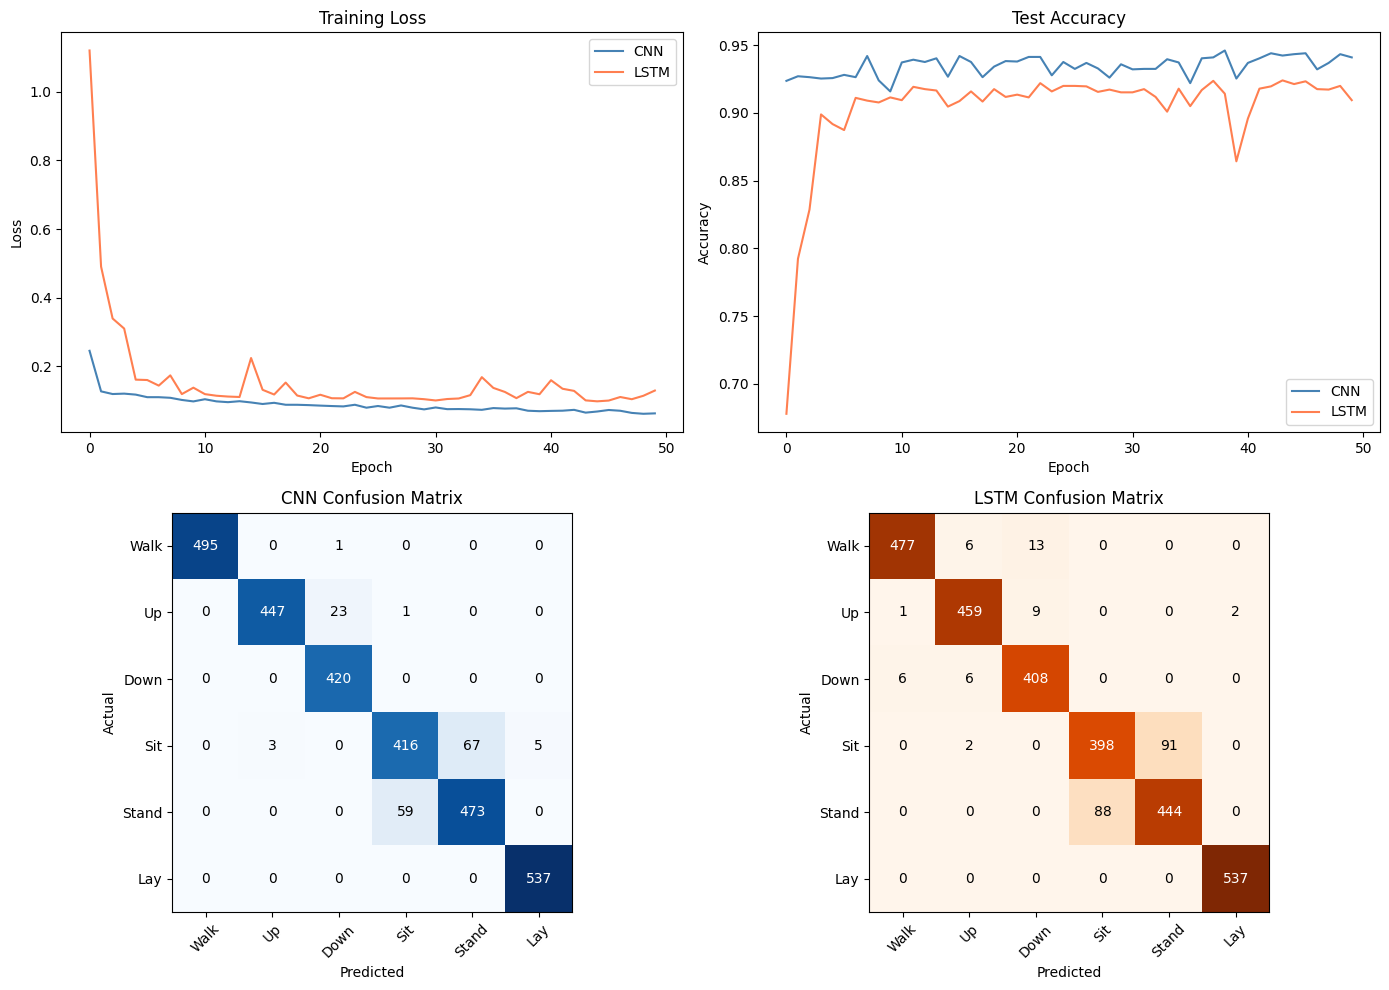


Model                  Accuracy   F1 Score     Params   Train Time
Random Forest             83.8%      83.6%        N/A          <1s
LSTM                      92.4%      92.5%       204K       467.2s
CNN                       94.6%      94.7%       145K       387.2s


In [18]:
# ============================================================
# Model Comparison: CNN vs LSTM
#
# 1. Training curves side by side
# 2. Summary comparison table
# 3. Confusion matrices for both models
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training loss comparison
axes[0][0].plot(cnn_history['train_loss'], label='CNN', color='steelblue')
axes[0][0].plot(lstm_history['train_loss'], label='LSTM', color='coral')
axes[0][0].set_title('Training Loss')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Loss')
axes[0][0].legend()

# Plot 2: Test accuracy comparison
axes[0][1].plot(cnn_history['test_acc'], label='CNN', color='steelblue')
axes[0][1].plot(lstm_history['test_acc'], label='LSTM', color='coral')
axes[0][1].set_title('Test Accuracy')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Accuracy')
axes[0][1].legend()

# Plot 3: CNN confusion matrix
activity_names = ['Walk', 'Up', 'Down', 'Sit', 'Stand', 'Lay']

cnn_model.load_state_dict(torch.load('../models/best_cnn.pth', weights_only=True))
cnn_model.eval()
cnn_preds, cnn_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        cnn_preds.extend(cnn_model(X_batch).argmax(dim=1).numpy())
        cnn_labels.extend(y_batch.numpy())

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
im = axes[1][0].imshow(cm_cnn, cmap='Blues')
axes[1][0].set_xticks(range(6))
axes[1][0].set_yticks(range(6))
axes[1][0].set_xticklabels(activity_names, rotation=45)
axes[1][0].set_yticklabels(activity_names)
axes[1][0].set_title('CNN Confusion Matrix')
axes[1][0].set_xlabel('Predicted')
axes[1][0].set_ylabel('Actual')
for i in range(6):
    for j in range(6):
        axes[1][0].text(j, i, str(cm_cnn[i][j]), ha='center', va='center',
                       color='white' if cm_cnn[i][j] > cm_cnn.max()/2 else 'black')

# Plot 4: LSTM confusion matrix
lstm_model.load_state_dict(torch.load('../models/best_lstm.pth', weights_only=True))
lstm_model.eval()
lstm_preds, lstm_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        lstm_preds.extend(lstm_model(X_batch).argmax(dim=1).numpy())
        lstm_labels.extend(y_batch.numpy())

cm_lstm = confusion_matrix(lstm_labels, lstm_preds)
im = axes[1][1].imshow(cm_lstm, cmap='Oranges')
axes[1][1].set_xticks(range(6))
axes[1][1].set_yticks(range(6))
axes[1][1].set_xticklabels(activity_names, rotation=45)
axes[1][1].set_yticklabels(activity_names)
axes[1][1].set_title('LSTM Confusion Matrix')
axes[1][1].set_xlabel('Predicted')
axes[1][1].set_ylabel('Actual')
for i in range(6):
    for j in range(6):
        axes[1][1].text(j, i, str(cm_lstm[i][j]), ha='center', va='center',
                       color='white' if cm_lstm[i][j] > cm_lstm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150)
plt.show()

# Print summary table
cnn_acc = accuracy_score(cnn_labels, cnn_preds)
cnn_f1 = f1_score(cnn_labels, cnn_preds, average='macro')
lstm_acc = accuracy_score(lstm_labels, lstm_preds)
lstm_f1 = f1_score(lstm_labels, lstm_preds, average='macro')

print("\n" + "="*60)
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Score':>10} {'Params':>10} {'Train Time':>12}")
print("="*60)
print(f"{'Random Forest':<20} {'83.8%':>10} {'83.6%':>10} {'N/A':>10} {'<1s':>12}")
print(f"{'LSTM':<20} {lstm_acc:>10.1%} {lstm_f1:>10.1%} {'204K':>10} {lstm_time:>11.1f}s")
print(f"{'CNN':<20} {cnn_acc:>10.1%} {cnn_f1:>10.1%} {'145K':>10} {cnn_time:>11.1f}s")
print("="*60)